In [1]:
#Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ML_Modelevaluation import SoilModel, HSdata_process

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import xgboost as xgb

import optuna
from optuna.samplers import TPESampler
from optuna.visualization import plot_param_importances, plot_optimization_history
import gc

c:\Users\hari1996\Documents\GitHub\MLpFEM\MLpFEM\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
######################## Define the text size of each plot globally ###########
SMALL_SIZE = 10
BIGGER_SIZE = 10

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

plt.rcParams["font.family"] = "Arial"
######################## Define the text size of each plot globally ###########

In [3]:
# =============================================================================
# Input structure HS - needs user interaction
# =============================================================================

input_column = ['E50ref', 'Eoedref', 'Eurref', 
                'phi','cref', 'psi', 
                'm', 'nu', 
                'Rf', 'K0NC', 'CellPressure']

triaxial_column = ['q', 'eps_y', 
                   'eps_v', 'p']

odometer_column = ['sig_y', 'eps_y_oed']

cell_pressure = [200]

In [4]:
# =============================================================================
# Modelevaluation HS
# ====================================================================

#input data for soil model
HS = HSdata_process(modelname='HardeningSoil_Database_20240715', 
                    CellPressure='CellPressure',
                    cellpressure_value=cell_pressure,
                    input_column= input_column,
                    triaxial_column = triaxial_column,
                    odoemeter_column= odometer_column)

input_parameters, output_triaxial, output_odometer, input_parameters_nan = HS.data_processing()

In [5]:
input_parameters = input_parameters.astype(float)

In [6]:
# Reference pressure - 100 kPa  
input_parameters.insert(loc=11, column='pref', value=float(100.0))
input_column.append('pref')

In [7]:
input_parameters

,E50ref,Eoedref,Eurref,phi,cref,psi,m,nu,Rf,K0NC,CellPressure,pref
0,47015.078131,37612.0,94030.2,36.942514,0.0,6.942514,0.457175,0.258691,0.750753,0.398987,200.0,100.0
2,69152.751019,55322.2,138305.6,30.196669,0.0,0.196669,0.667083,0.225450,0.951141,0.497030,200.0,100.0
3,28709.171082,22967.3,57418.4,34.301510,0.0,4.301510,0.445161,0.124509,0.889554,0.436452,200.0,100.0
4,29401.355872,23521.0,58802.8,33.564483,0.0,3.564483,0.523623,0.295160,0.867171,0.447125,200.0,100.0
5,50465.270589,40372.2,100930.6,35.461038,0.0,5.461038,0.400504,0.167644,0.859915,0.419851,200.0,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...
40494,15646.914401,18776.2,62587.7,31.524586,0.0,0.000000,0.645787,0.183601,0.729768,0.477136,200.0,100.0
40495,51792.300857,62150.7,207169.3,28.458506,0.0,0.000000,0.603964,0.296719,0.783701,0.523478,200.0,100.0
40497,22878.896370,27454.6,91515.6,35.887609,0.0,0.000000,0.320329,0.170195,0.749667,0.413803,200.0,100.0
40498,27185.502230,32622.6,108742.1,33.554801,0.0,0.000000,0.471491,0.265357,0.807118,0.447266,200.0,100.0


In [8]:
def x_array(x_matrix):
    X_return = []
    for s in x_matrix:
        # Remove '[' and ']' characters, split by '\n' to get individual lines
        s = str(s)
        lines = s.strip('[]').split(',')
        values = []
        for line in lines:
            # Split each line by spaces, convert values to floats, and extend the list
            values.extend([float(val) for val in line.split()])   
        X_return.append(np.array(values))
    X_return = np.array(X_return)
    return X_return

In [9]:
#triaxial test
q = x_array(output_triaxial.iloc[:,0])
eps_y = x_array(output_triaxial.iloc[:,1])
eps_vol = x_array(output_triaxial.iloc[:,2])
p = x_array(output_triaxial.iloc[:,3])

#oedometer test
sig_1 = x_array(output_odometer.iloc[:,0])
eps_y_oed = x_array(output_odometer.iloc[:,1])

In [10]:
soil_model = SoilModel()

df_sig = pd.DataFrame()
df_eps = pd.DataFrame()

for sig, eps in zip(sig_1, eps_y_oed):
    min_index = np.argmin(sig)
    degree = 15

    # Loading
    eps1_section_1 = eps[:min_index + 1]
    sig1_section_1 = sig[:min_index + 1]

    # Unloading
    eps1_section_2 = eps[min_index:]
    sig1_section_2 = sig[min_index:]

    # Filter for sigma not less than -50
    mask = sig1_section_2 <= -50
    cutoff_indices = np.where(~mask)[0]  # Indices that do not meet the condition
    
    if len(cutoff_indices) > 0:
        #print("Indices being cut off for sig1_section_2:", cutoff_indices)
        eps1_section_2 = eps1_section_2[:cutoff_indices[0]]
        sig1_section_2 = sig1_section_2[:cutoff_indices[0]]
    
    eps1_section_1_syn = np.linspace(0, min(eps1_section_1), num=375)
    eps1_section_2_syn = np.linspace(min(eps1_section_1), max(eps1_section_2), num=375)

    sig1_pred_section_1 = soil_model.interpolation_scikit(x_true=eps1_section_1, y_true=sig1_section_1, x_check=eps1_section_1_syn, degree=degree)
    sig1_pred_section_2 = soil_model.interpolation_scikit(x_true=eps1_section_2, y_true=sig1_section_2, x_check=eps1_section_2_syn, degree=degree)

    # Convert to DataFrame and transpose
    sig1_pred_section_1_df = pd.DataFrame(sig1_pred_section_1).T
    sig1_pred_section_2_df = pd.DataFrame(sig1_pred_section_2).T
    eps1_section_1_syn_df = pd.DataFrame(eps1_section_1_syn).T
    eps1_section_2_syn_df = pd.DataFrame(eps1_section_2_syn).T

    # Concatenate horizontally
    sig_combined_df = pd.concat([sig1_pred_section_1_df, sig1_pred_section_2_df], axis=1)
    eps_combined_df = pd.concat([eps1_section_1_syn_df, eps1_section_2_syn_df], axis=1)

    df_sig = pd.concat([df_sig, sig_combined_df], ignore_index=True)
    df_eps = pd.concat([df_eps, eps_combined_df], ignore_index=True)

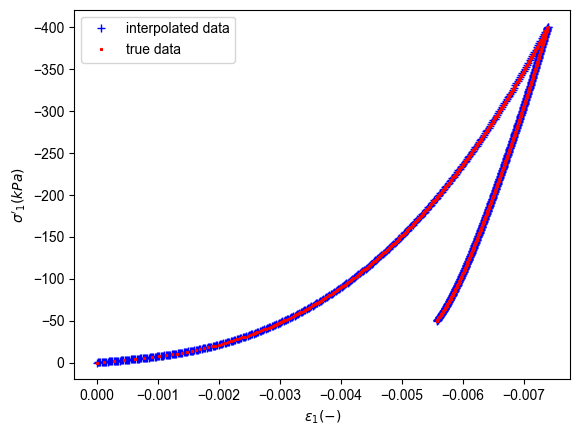

In [11]:
num_fig = 1 # Choose the figure number to plot

plt.figure()
plt.plot(df_eps.iloc[num_fig, :], df_sig.iloc[num_fig, :], 'b+', label = 'interpolated data')
plt.plot(eps_y_oed[num_fig, :], sig_1[num_fig, :], 'r*', label = 'true data', markersize = 2)
plt.xlabel('$\\varepsilon_1 (-)$')  # Add appropriate label for x-axis
plt.ylabel("$\sigma'_1 (kPa)$")  # Add appropriate label for y-axis
plt.legend()
plt.gca().invert_xaxis()    # Correct function to invert the x-axis
plt.gca().invert_yaxis()    # Correct function to invert the x-axis

In [12]:
df_q = pd.DataFrame()
df_p = pd.DataFrame()

i = 0
for q_a, p_a in zip(q, p):
    max_q, min_q = max(q_a), min(q_a)
    max_p, min_p = max(p_a), min(p_a)
    
    q_export = np.linspace(min_q, max_q, num=250)
    p_export = np.linspace(max_p, min_p, num=250)

    # Convert to DataFrame and transpose
    q_export = pd.DataFrame(q_export).T
    p_export = pd.DataFrame(p_export).T

    # Concatenate horizontally
    df_q = pd.concat([df_q, q_export], axis=0)
    df_p = pd.concat([df_p, p_export], axis=0)

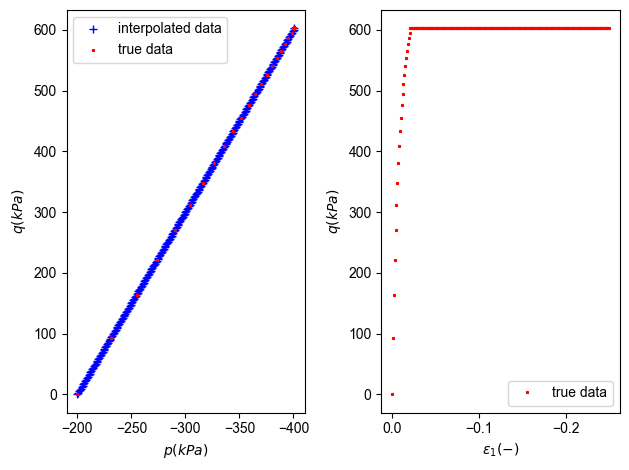

In [13]:
num_fig = 0

fig, axs=plt.subplots(1,2)

axs[0].plot(df_p.iloc[num_fig, :], df_q.iloc[num_fig, :], 'b+', label = 'interpolated data')
axs[0].plot(p[num_fig, :], q[num_fig, :], 'r*', label = 'true data', markersize = 2)

axs[0].set_xlabel('$p (kPa)$')
axs[0].set_ylabel("$q (kPa)$")
axs[0].invert_xaxis()
axs[0].legend()

axs[1].plot(eps_y[num_fig, :], q[num_fig, :], 'r*', label = 'true data', markersize = 2)
axs[1].set_xlabel('$\\varepsilon_1 (-)$')
axs[1].set_ylabel("$q (kPa)$")
axs[1].invert_xaxis()
axs[1].legend()

plt.tight_layout()

In [14]:
# Check for NaN values in df_sig
nan_in_df_sig = df_sig.isna().any().any()
print(f"NaN values in df_sig: {nan_in_df_sig}")

# Check for NaN values in df_eps
nan_in_df_eps = df_eps.isna().any().any()
print(f"NaN values in df_eps: {nan_in_df_eps}")

NaN values in df_sig: False
NaN values in df_eps: False


In [15]:
X_triax = np.hstack((q, eps_y, eps_vol, eps_y))
X_triax = pd.DataFrame(X_triax)

# Ensure that all DataFrames have unique indices
df_q = df_q.reset_index(drop=True)
df_p = df_p.reset_index(drop=True)
X_triax = X_triax.reset_index(drop=True)

# Concatenate DataFrames
X_triax = pd.concat([X_triax, df_q, df_p], ignore_index=False, sort=False, axis=1)
X_oedo = pd.concat([df_sig, df_eps], ignore_index = True, sort = False, axis = 1)

In [16]:
print("Triaxial test:", len(X_triax.columns))
print("Oedometer test:", len(X_oedo.columns))

Triaxial test: 1500
Oedometer test: 1500


In [17]:
X = pd.concat([X_triax, X_oedo], ignore_index = True, sort = False, axis = 1)
y = input_parameters

In [18]:
X

,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
0,0.0,93.26830,164.18549,221.95807,270.59355,312.32252,348.56347,380.32557,408.36215,433.25897,...,-0.006814,-0.006806,-0.006797,-0.006789,-0.006780,-0.006771,-0.006763,-0.006754,-0.006745,-0.006737
1,0.0,135.19789,205.80227,251.43260,282.86647,305.47981,322.32796,335.26250,345.45055,353.65789,...,-0.005620,-0.005615,-0.005610,-0.005605,-0.005600,-0.005595,-0.005590,-0.005586,-0.005581,-0.005576
2,0.0,66.51164,116.87364,155.90200,188.72435,217.06242,241.92024,263.95612,283.63835,301.31991,...,-0.011370,-0.011356,-0.011342,-0.011328,-0.011314,-0.011301,-0.011287,-0.011273,-0.011259,-0.011245
3,0.0,67.57117,118.42081,159.57555,194.11551,223.72066,249.44197,272.00787,291.94921,309.67680,...,-0.011599,-0.011587,-0.011574,-0.011561,-0.011549,-0.011536,-0.011523,-0.011511,-0.011498,-0.011486
4,0.0,101.15762,170.09241,223.49692,266.91478,303.08653,333.67900,359.83510,382.39166,401.98726,...,-0.006358,-0.006350,-0.006342,-0.006334,-0.006326,-0.006319,-0.006311,-0.006303,-0.006295,-0.006287
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34006,0.0,37.70723,70.13712,98.58523,123.91356,146.71424,167.41247,186.32573,203.69922,219.72778,...,-0.017054,-0.017043,-0.017032,-0.017021,-0.017009,-0.016998,-0.016987,-0.016976,-0.016964,-0.016953
34007,0.0,100.08269,164.17317,210.05852,244.59925,271.44335,292.82114,310.17001,324.49597,336.50006,...,-0.005174,-0.005171,-0.005168,-0.005165,-0.005162,-0.005159,-0.005156,-0.005153,-0.005150,-0.005147
34008,0.0,42.63763,80.74051,115.05960,146.16584,174.50402,200.43395,224.25034,246.19913,266.48819,...,-0.010228,-0.010219,-0.010210,-0.010202,-0.010193,-0.010184,-0.010175,-0.010166,-0.010157,-0.010148
34009,0.0,56.96362,104.01111,143.81023,178.02944,207.80272,233.94961,257.09040,277.70554,296.17612,...,-0.008993,-0.008986,-0.008979,-0.008972,-0.008966,-0.008959,-0.008952,-0.008946,-0.008939,-0.008932


In [19]:
y

,E50ref,Eoedref,Eurref,phi,cref,psi,m,nu,Rf,K0NC,CellPressure,pref
0,47015.078131,37612.0,94030.2,36.942514,0.0,6.942514,0.457175,0.258691,0.750753,0.398987,200.0,100.0
2,69152.751019,55322.2,138305.6,30.196669,0.0,0.196669,0.667083,0.225450,0.951141,0.497030,200.0,100.0
3,28709.171082,22967.3,57418.4,34.301510,0.0,4.301510,0.445161,0.124509,0.889554,0.436452,200.0,100.0
4,29401.355872,23521.0,58802.8,33.564483,0.0,3.564483,0.523623,0.295160,0.867171,0.447125,200.0,100.0
5,50465.270589,40372.2,100930.6,35.461038,0.0,5.461038,0.400504,0.167644,0.859915,0.419851,200.0,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...
40494,15646.914401,18776.2,62587.7,31.524586,0.0,0.000000,0.645787,0.183601,0.729768,0.477136,200.0,100.0
40495,51792.300857,62150.7,207169.3,28.458506,0.0,0.000000,0.603964,0.296719,0.783701,0.523478,200.0,100.0
40497,22878.896370,27454.6,91515.6,35.887609,0.0,0.000000,0.320329,0.170195,0.749667,0.413803,200.0,100.0
40498,27185.502230,32622.6,108742.1,33.554801,0.0,0.000000,0.471491,0.265357,0.807118,0.447266,200.0,100.0


In [20]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_eval, y_test, y_eval = train_test_split(X_temp, y_temp, test_size=0.33, random_state=42)

In [21]:
def objective(trial):
    param = {
        "objective": "reg:squarederror",
        'n_estimators': trial.suggest_int('n_estimators', 60, 120),
        "verbosity": 1,
        "learning_rate": trial.suggest_float("learning_rate", 0.05, 0.5, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "subsample": trial.suggest_float("subsample", 0.05, 0.8),
    }

    model = xgb.XGBRegressor(**param, random_state=42, early_stopping_rounds=5, tree_method = 'hist')
    model.fit(X_train, y_train, eval_set=[(X_train, y_train),(X_eval,y_eval)], verbose=False)
    y_pred = model.predict(X_eval)
    r2 = r2_score(y_true = y_eval, y_pred = y_pred)
    
    del model # Deleting the model to free up memory

    return r2

sampler = TPESampler(seed=10)  # Make the sampler behave in a deterministic way.
study = optuna.create_study(sampler = sampler, direction='maximize')
study.optimize(objective, n_trials=100, callbacks=[lambda study, trial: gc.collect()])

[I 2024-07-26 18:43:19,111] A new study created in memory with name: no-name-5a38d79d-f4fc-45be-90b4-515f148330b9
[I 2024-07-26 18:55:33,697] Trial 0 finished with value: -284301.6473647917 and parameters: {'n_estimators': 107, 'learning_rate': 0.05244715727819381, 'max_depth': 6, 'subsample': 0.611602911903959}. Best is trial 0 with value: -284301.6473647917.
[I 2024-07-26 19:03:12,220] Trial 1 finished with value: -4078.4053345910684 and parameters: {'n_estimators': 90, 'learning_rate': 0.08390090586558743, 'max_depth': 4, 'subsample': 0.6203980341492191}. Best is trial 1 with value: -4078.4053345910684.
[I 2024-07-26 19:13:23,408] Trial 2 finished with value: -4126923.7949344586 and parameters: {'n_estimators': 70, 'learning_rate': 0.06127873882343843, 'max_depth': 7, 'subsample': 0.7650450096462025}. Best is trial 1 with value: -4078.4053345910684.
[I 2024-07-26 19:21:55,878] Trial 3 finished with value: -15.690062084523897 and parameters: {'n_estimators': 60, 'learning_rate': 0.16

In [22]:
#del model

best_params = {
    'objective': 'reg:squarederror',
    'n_estimators': 100,
    "verbosity": 1,
    'learning_rate': 0.2,
    'max_depth': 8,
    'subsample': 0.7,
}

# Update with the best hyperparameters
#best_params.update(study.best_params)

# Create the final XGBRegressor with the best hyperparameters
final_model = xgb.XGBRegressor(**best_params, random_state=42, early_stopping_rounds=5, tree_method = 'hist')

# Train the final model with the best hyperparameters
final_model.fit(X_train, y_train, eval_set=[(X_train, y_train),(X_eval,y_eval)], verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=5,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.2, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=8, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [23]:
best_params

{'objective': 'reg:squarederror',
 'n_estimators': 100,
 'verbosity': 1,
 'learning_rate': 0.2,
 'max_depth': 8,
 'subsample': 0.7}

In [24]:
# Plot optimization history
plot_optimization_history(study)

In [25]:
# Plot parameter importances
plot_param_importances(study)

In [34]:
input_column_label = ['$E_{50}^{ref}$', '$E_{oed}^{ref}$', '$E_{ur}^{ref}$', 
                      "$\\varphi$'", "$c_{ref}$'",'$\psi$', 
                      '${m}$', '${ν_{ur}}$', 
                      '${R_f}$', '$K_0^{NC}$','Cell pressure', '$p_{ref}$']


cm = 1/2.54  # centimeters in inches

# check performance on test data
y_pred = final_model.predict(X_test)

In [35]:
score_all = []
mse_all = []
for i in range(y_pred.shape[1]):
    y_true_col = y_test.values[:, i]
    y_pred_col = y_pred[:, i]

    score, mse = HS.eval_error(y_true = y_true_col, y_pred=y_pred_col)
    score_all.append(score), mse_all.append(mse)    
    HS.error_plot(y_true = y_true_col, y_pred = y_pred_col, title = f'Parameter {input_column_label[i]}, $R^2$ = {score:.4f}')
    
    # Change the figsize
    plt.gcf().set_figwidth(5.8*cm)
    plt.gcf().set_figheight(5.8*cm)
    plt.xticks(rotation=45)
    plt.subplots_adjust(left=0.33, right=0.95, bottom=0.30, top=0.90)
    plt.savefig(f'..\graphics\{i}_{input_column[i]}_test_data.png', dpi = 500)
    plt.close()

c:\Users\hari1996\Documents\GitHub\MLpFEM\MLpFEM\Lib\site-packages\sklearn\metrics\_regression.py:624: RuntimeWarning:

divide by zero encountered in divide

c:\Users\hari1996\Documents\GitHub\MLpFEM\MLpFEM\Lib\site-packages\sklearn\metrics\_regression.py:624: RuntimeWarning:

divide by zero encountered in divide

c:\Users\hari1996\Documents\GitHub\MLpFEM\MLpFEM\Lib\site-packages\sklearn\metrics\_regression.py:624: RuntimeWarning:

divide by zero encountered in divide



In [28]:
score_all

[0.9993557877146513,
 0.9999316939865914,
 0.9943600830074123,
 0.999973504664345,
 -inf,
 0.9997648151172518,
 0.9998437815184995,
 0.9954277808958599,
 0.9704292306108593,
 0.9999418985358577,
 -inf,
 -inf]

In [29]:
from sklearn.metrics import PredictionErrorDisplay
nrows= 3
ncols= 3
figsize= (17.4*cm, 17.4*cm)

y_true = y_test
y_pred = pd.DataFrame(y_pred, columns=input_column)

plot_data_column = [0,1,2,3,5,6,7,8,9]
score = score_all
save_path=r'..\graphics\20_all_parameters_test_data.png'

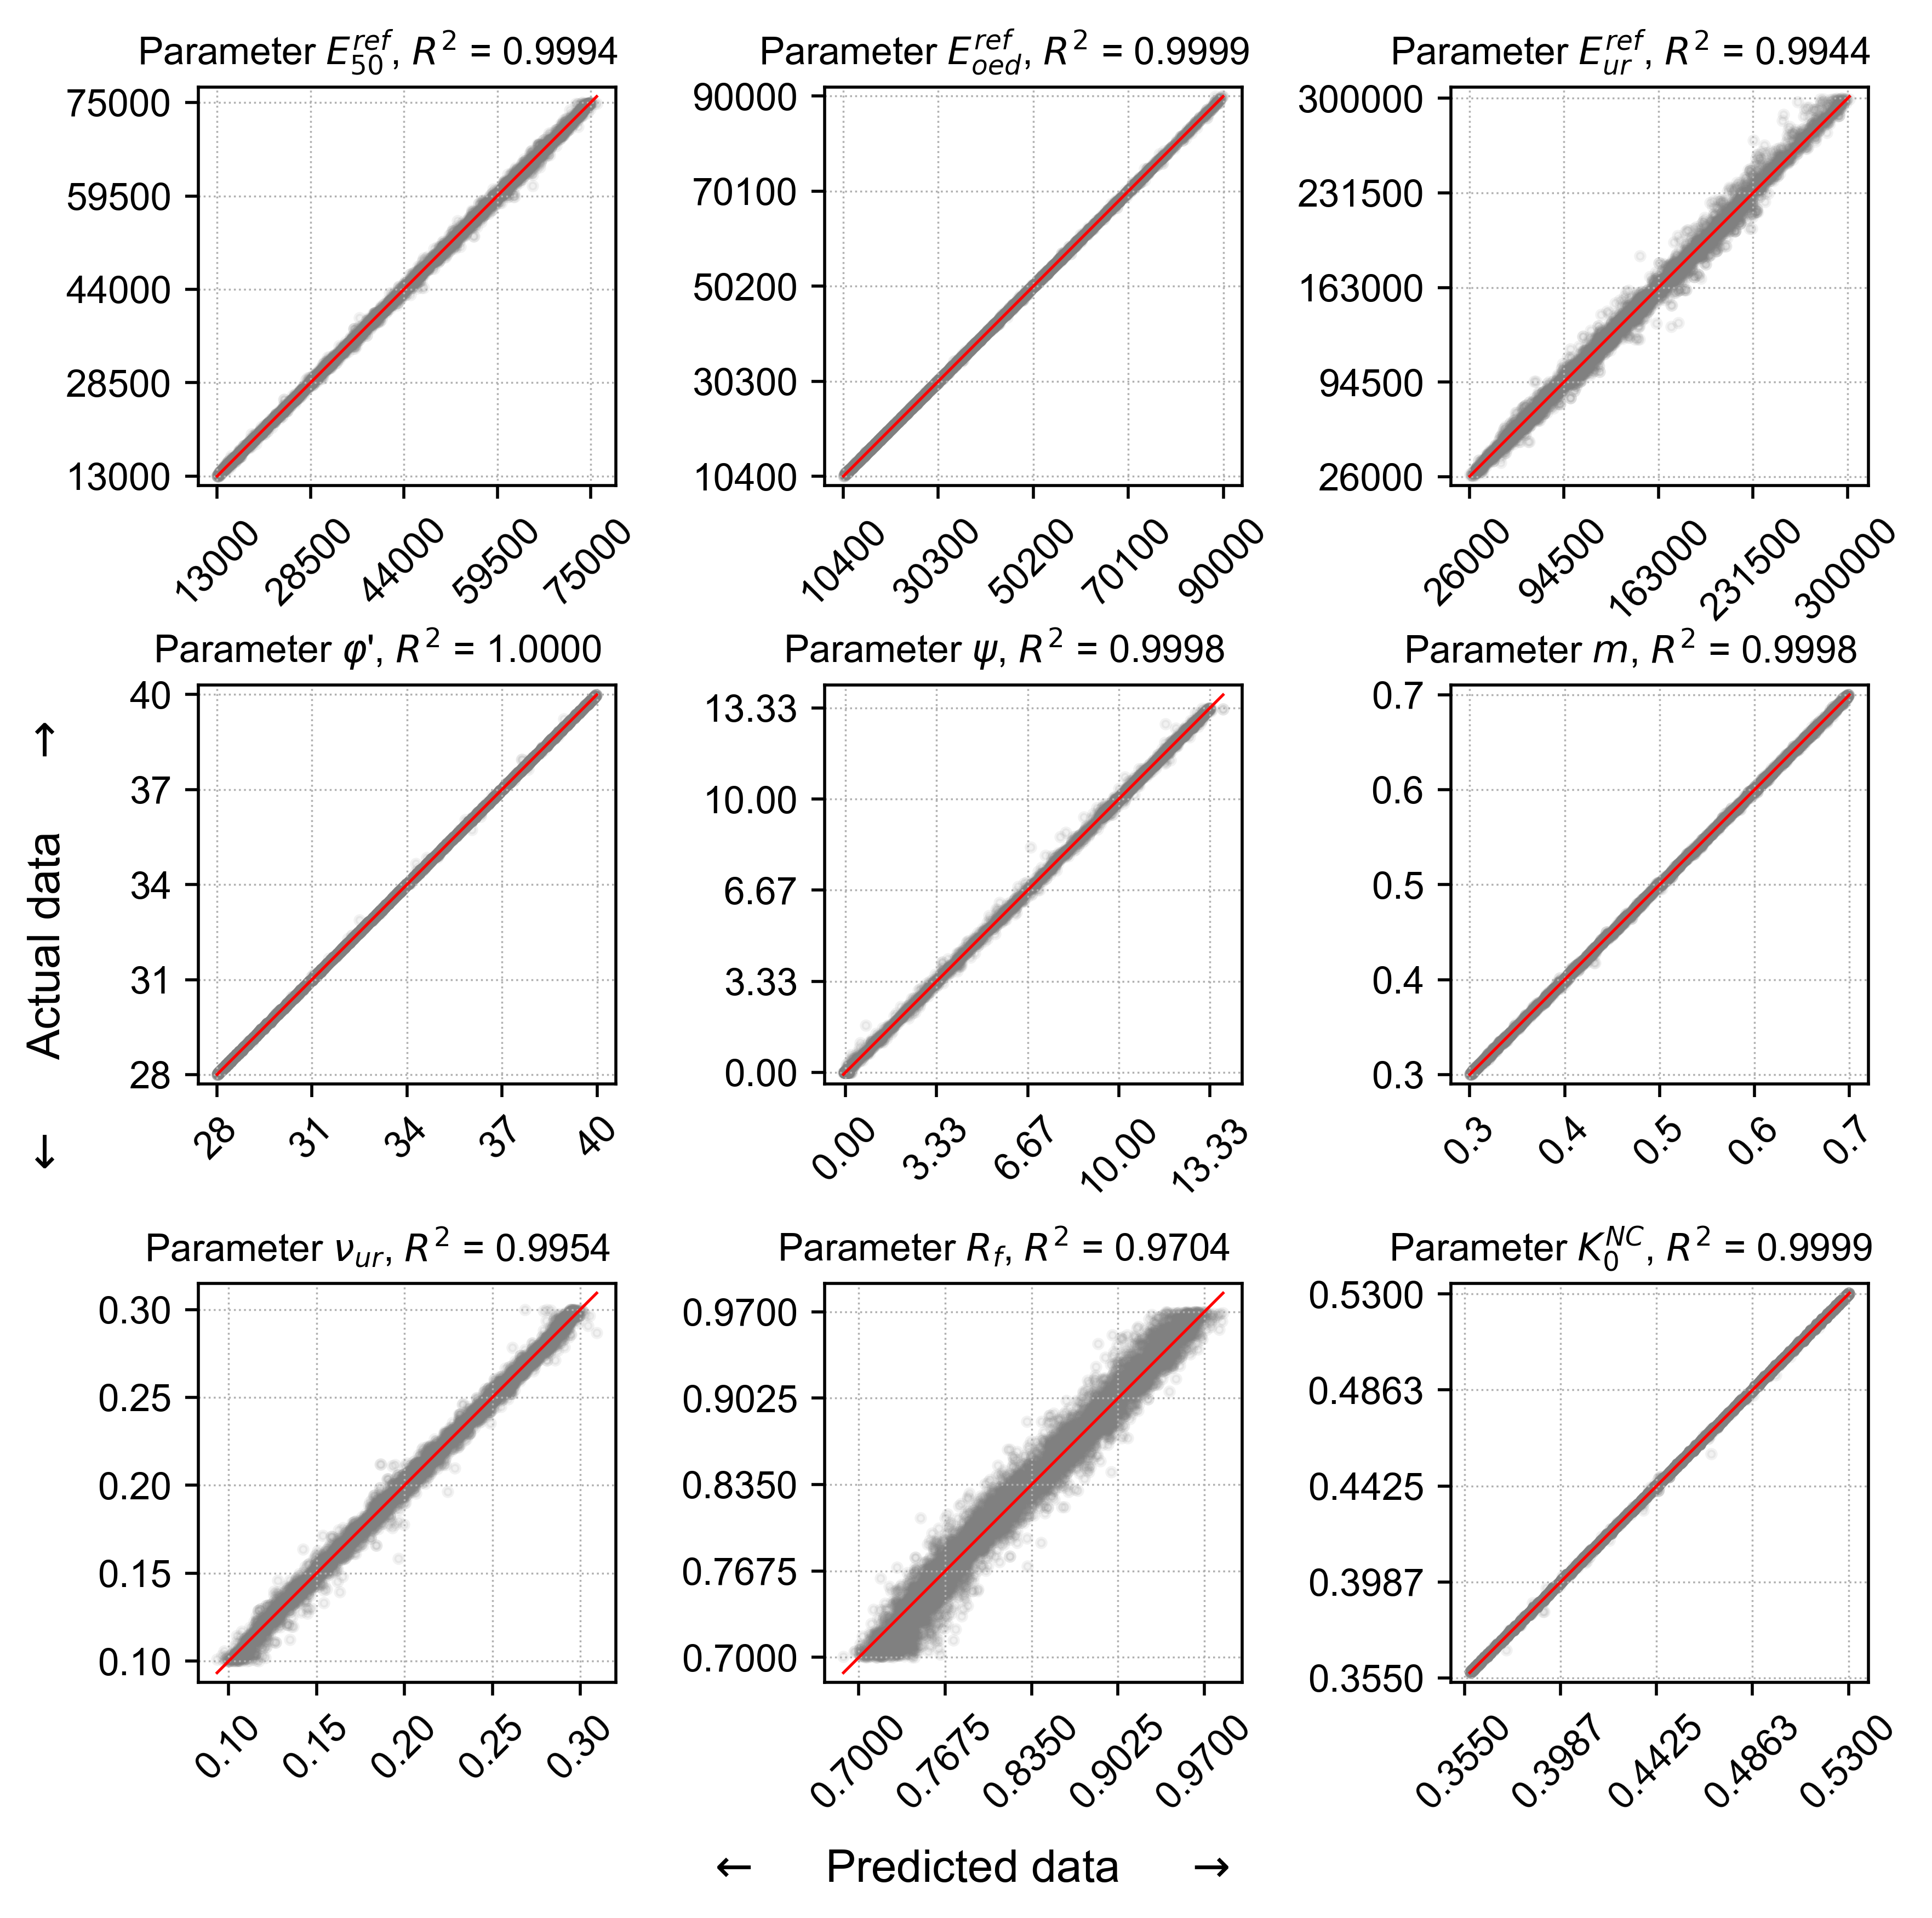

In [30]:
plot_data_column = [0,1,2,3,5,6,7,8,9]

axis_limit = [(13000, 75000), (13000*0.8, 75000*1.2), (13000*2, 75000*4), (28,40), (0, 13.33), (0.3, 0.7), (0.1, 0.3), (0.7, 0.97), (0.355,0.53)]

# Define plot structure
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, dpi=500)

for i in range(len(plot_data_column)):  
    y_true_col = y_true.iloc[:, int(plot_data_column[i])]
    y_pred_col = y_pred.iloc[:, int(plot_data_column[i])]

    ped = PredictionErrorDisplay.from_predictions(y_true=y_true_col,
                                                y_pred=y_pred_col,
                                                kind="actual_vs_predicted",
                                                subsample=100000,
                                                ax=axs[i // ncols, i % ncols],
                                                random_state=0, 
                                                line_kwargs={"color": "red", "linewidth": 0.75, "linestyle": "solid", "alpha": 1},)

    ped.ax_.set_xlabel("")  # Set x label
    ped.ax_.set_ylabel("")  # Set y label

    x, y = axis_limit[i][0], axis_limit[i][1]
    
    ped.ax_.set_xticks(np.arange(x, y+0.001, (y-x)/4))
    #ped.ax_.set_xlim(left=x*0.99, right=y*1.01)
    ped.ax_.set_yticks(np.arange(x, y*1.001, (y-x)/4))
    #ped.ax_.set_ylim(bottom=x*0.99, top=y*1.01)

    ped.ax_.grid(linewidth = 0.5, linestyle = 'dotted')

    scatter = ped.figure_.axes[i].collections[0]
    scatter.set_color('gray')  
    scatter.set_sizes([5]) 
    scatter.set_alpha([0.1]) 
    
    title_text = ped.ax_.set_title(f'Parameter {input_column_label[int(plot_data_column[i])]}, $R^2$ = {score[int(plot_data_column[i])]:.4f}')
    title_pos = title_text.get_position()
    title_text.set_position((title_pos[0] - 0.07, title_pos[1] + 100))

    ax = ped.ax_
    ax.set_xticks(ax.get_xticks())
    ax.tick_params(axis='x', rotation=45)


fig.text(0.5, 0.01, r'$\leftarrow$     Predicted data     $\rightarrow$', ha='center', va='center', fontsize=12)
fig.text(0.01, 0.5, r'$\leftarrow$     Actual data     $\rightarrow$', ha='center', va='center', rotation='vertical', fontsize=12)


plt.subplots_adjust(left=0.09, right=0.98, top=0.96, bottom=0.11, wspace=0.5, hspace=0.5)
plt.savefig(save_path, dpi=1000)

In [31]:
# check performance on training data
y_pred = final_model.predict(X_train)
for i in range(y_pred.shape[1]-1):
    y_true_col = y_train.values[:, i]
    y_pred_col = y_pred[:, i]

    score, mse = HS.eval_error(y_true = y_true_col, y_pred=y_pred_col)
    HS.error_plot(y_true = y_true_col, y_pred = y_pred_col, title = f'Parameter {input_column_label[i]}, $R^2$ = {score:.3f}')
    # Change the figsize
    plt.gcf().set_figwidth(6*cm)
    plt.gcf().set_figheight(6*cm)
    plt.xticks(rotation=45)
    plt.subplots_adjust(left=0.32, right=0.95, bottom=0.3, top=0.90)
    plt.savefig(f'..\graphics\{i+10}_{input_column[i]}_train_data.png', dpi = 500)
    plt.close()

c:\Users\hari1996\Documents\GitHub\MLpFEM\MLpFEM\Lib\site-packages\sklearn\metrics\_regression.py:624: RuntimeWarning:

divide by zero encountered in divide

c:\Users\hari1996\Documents\GitHub\MLpFEM\MLpFEM\Lib\site-packages\sklearn\metrics\_regression.py:624: RuntimeWarning:

divide by zero encountered in divide



In [32]:
X = pd.concat([X_triax, X_oedo], ignore_index = True, sort = False, axis = 1)
y = input_parameters

In [33]:
# Create the final XGBRegressor with the best hyperparameters
final_model = xgb.XGBRegressor(**best_params)
final_model.fit(X,y)
print(f"Cellpressure model with {cell_pressure} kPa trained successfully")
final_model.save_model(f"A_HS_model_200_kPa.bin")

Cellpressure model with [200] kPa trained successfully


c:\Users\hari1996\Documents\GitHub\MLpFEM\MLpFEM\Lib\site-packages\xgboost\core.py:160: UserWarning:

[02:54:24] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.

